In [1]:
import pandas as pd

# 1 - mzML parser ON
#### input mzml/AMP_ON
#### output mzml_parsed/ON

In [12]:
# Submit the SLURM job for mzml_parser_1.sh
!sbatch core/backend/STD/mzml_parser_1_ON.sh


Submitted batch job 21016550


In [10]:
# sum = pd.read_parquet('Projects/STD/mzml_parsed/ON/sum/df_transition_summed_1_test.parquet')
# sum

In [152]:
import pandas as pd
df = pd.read_parquet('Projects/STD/mzml_parsed/ON/df_mzml_parser_1_FAME.parquet')
# Print number of unique Sample_ID
print(len(df['Sample_ID'].unique()))
df

1


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition
0,None,227.1,183.0,3.019117,40.980003,FAME_OzoneOn,227.1 -> 183.0
1,None,227.1,183.0,3.034933,40.520004,FAME_OzoneOn,227.1 -> 183.0
2,None,227.1,183.0,3.050783,40.320004,FAME_OzoneOn,227.1 -> 183.0
3,None,227.1,183.0,3.066633,40.380001,FAME_OzoneOn,227.1 -> 183.0
4,None,227.1,183.0,3.082500,41.360004,FAME_OzoneOn,227.1 -> 183.0
...,...,...,...,...,...,...,...
183107,None,533.5,183.0,27.748300,40.700005,FAME_OzoneOn,533.5 -> 183.0
183108,None,533.5,183.0,27.764150,40.700005,FAME_OzoneOn,533.5 -> 183.0
183109,None,533.5,183.0,27.780000,40.760002,FAME_OzoneOn,533.5 -> 183.0
183110,None,533.5,183.0,27.795850,40.900002,FAME_OzoneOn,533.5 -> 183.0


In [154]:
# Ensure 'Parent_Ion' is of float type
df['Parent_Ion'] = df['Parent_Ion'].astype(float)

# Define the target float value
target_value = 533.3

# Set a tolerance for floating-point comparison
tolerance = 0.3  # Adjust the tolerance as needed

# Filter the DataFrame for rows where 'Parent_Ion' is approximately equal to the target value
sorted_filtered_lipids = df.loc[
    (df['Parent_Ion'] >= target_value - tolerance) &
    (df['Parent_Ion'] <= target_value + tolerance)
]

# Ensure 'OzESI_Intensity' is of numeric type
sorted_filtered_lipids['OzESI_Intensity'] = pd.to_numeric(
    sorted_filtered_lipids['OzESI_Intensity'], errors='coerce'
)

# Sort by 'OzESI_Intensity' from high to low
sorted_filtered_lipids = sorted_filtered_lipids.sort_values(
    by='OzESI_Intensity', ascending=False
)

# Display the first 30 rows of the sorted DataFrame
sorted_filtered_lipids.head(30)


/scratch/negishi/iyer95/conda/CLAW/lib/python3.7/site-packages/ipykernel_launcher.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition
179611,None,533.4,183.0,21.963583,4006.720215,FAME_OzoneOn,533.4 -> 183.0
179612,None,533.4,183.0,21.979433,3890.160156,FAME_OzoneOn,533.4 -> 183.0
179610,None,533.4,183.0,21.947733,3792.200195,FAME_OzoneOn,533.4 -> 183.0
179613,None,533.4,183.0,21.995283,3129.360107,FAME_OzoneOn,533.4 -> 183.0
179609,None,533.4,183.0,21.931883,2648.520264,FAME_OzoneOn,533.4 -> 183.0
179614,None,533.4,183.0,22.011133,2608.860107,FAME_OzoneOn,533.4 -> 183.0
179615,None,533.4,183.0,22.027000,2396.380127,FAME_OzoneOn,533.4 -> 183.0
179617,None,533.4,183.0,22.058700,2044.720093,FAME_OzoneOn,533.4 -> 183.0
179616,None,533.4,183.0,22.042850,2004.900146,FAME_OzoneOn,533.4 -> 183.0
179608,None,533.4,183.0,21.916033,1989.620117,FAME_OzoneOn,533.4 -> 183.0


In [14]:
unique_values = df['Sample_ID'].unique()
print(unique_values)


['FAME_OzoneOn']


In [15]:
# Ensure the Parent_Ion column is numeric
df['Parent_Ion'] = pd.to_numeric(df['Parent_Ion'], errors='coerce')

# Set tolerance for Parent_Ion comparison
tolerance = 0.2

# Filter based on Parent_Ion and Retention_Time window
df_filtered = df[(df['Parent_Ion'] >= 423.4 - tolerance) & 
                 (df['Parent_Ion'] <= 423.4 + tolerance) &
                 (df['Retention_Time'] >= 5) &
                 (df['Retention_Time'] <= 15)]

# Sort the filtered DataFrame by Retention_Time
df_filtered_sorted = df_filtered.sort_values(by='Retention_Time', ascending=True)

# Display the sorted DataFrame
df_filtered_sorted


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition
108111,None,423.3,183.0,5.008100,181.620010,FAME_OzoneOn,423.3 -> 183.0
108112,None,423.3,183.0,5.023950,117.180008,FAME_OzoneOn,423.3 -> 183.0
108113,None,423.3,183.0,5.039800,113.960007,FAME_OzoneOn,423.3 -> 183.0
108114,None,423.3,183.0,5.055650,191.380020,FAME_OzoneOn,423.3 -> 183.0
108115,None,423.3,183.0,5.071500,296.240021,FAME_OzoneOn,423.3 -> 183.0
...,...,...,...,...,...,...,...
108737,None,423.3,183.0,14.931117,172.120010,FAME_OzoneOn,423.3 -> 183.0
108738,None,423.3,183.0,14.946967,250.640015,FAME_OzoneOn,423.3 -> 183.0
108739,None,423.3,183.0,14.962817,275.900024,FAME_OzoneOn,423.3 -> 183.0
108740,None,423.3,183.0,14.978667,300.360016,FAME_OzoneOn,423.3 -> 183.0


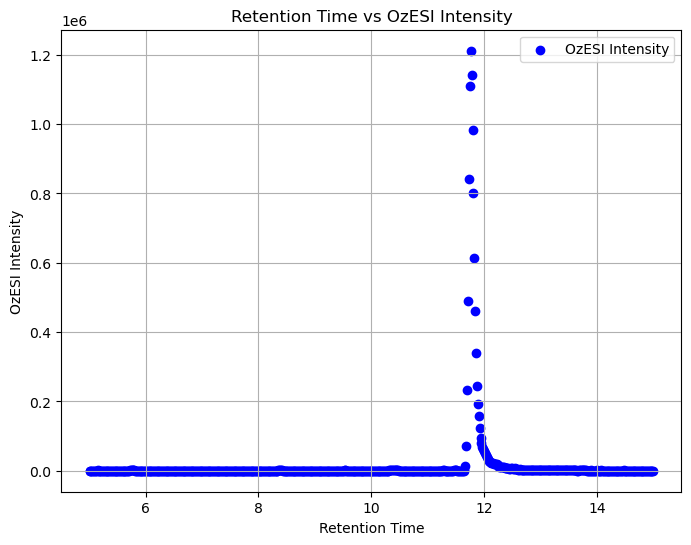

In [16]:
import matplotlib.pyplot as plt

# Plot the filtered data
plt.figure(figsize=(8, 6))
plt.scatter(df_filtered_sorted['Retention_Time'], df_filtered_sorted['OzESI_Intensity'], color='blue', label='OzESI Intensity')

# Add labels and title
plt.xlabel('Retention Time')
plt.ylabel('OzESI Intensity')
plt.title('Retention Time vs OzESI Intensity')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


# 2 - Sample

In [18]:
input_dir = 'Projects/STD/mzml_parsed/ON/'
import glob; num_files = len(glob.glob('Projects/STD/mzml_parsed/ON/*.parquet'))
num_files   


1

In [20]:
# change mzml parsed df
step1 = pd.read_parquet('Projects/STD/mzml_parsed/ON/df_mzml_parser_1_FAME.parquet')
# step1 = step1[step1['Sample_ID'] == '11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-0_MRMs_O3on_01']
# step1.to_parquet('Projects/AMP/mzml_parsed/ON/hippo_m1_FAD245_WT.parquet')


step1

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition
0,None,227.1,183.0,3.019117,40.980003,FAME_OzoneOn,227.1 -> 183.0
1,None,227.1,183.0,3.034933,40.520004,FAME_OzoneOn,227.1 -> 183.0
2,None,227.1,183.0,3.050783,40.320004,FAME_OzoneOn,227.1 -> 183.0
3,None,227.1,183.0,3.066633,40.380001,FAME_OzoneOn,227.1 -> 183.0
4,None,227.1,183.0,3.082500,41.360004,FAME_OzoneOn,227.1 -> 183.0
...,...,...,...,...,...,...,...
183107,None,533.5,183.0,27.748300,40.700005,FAME_OzoneOn,533.5 -> 183.0
183108,None,533.5,183.0,27.764150,40.700005,FAME_OzoneOn,533.5 -> 183.0
183109,None,533.5,183.0,27.780000,40.760002,FAME_OzoneOn,533.5 -> 183.0
183110,None,533.5,183.0,27.795850,40.900002,FAME_OzoneOn,533.5 -> 183.0


In [80]:
# Submit the SLURM job for !sbatch core/backend/sample_2.sh
!sbatch core/backend/STD/sample_2_ON.sh


Submitted batch job 21069815


In [2]:
import pandas as pd
df_sample = pd.read_parquet('Projects/STD/samples/ON/df_sample_2_FAME_ON.parquet')
#print number of unique Sample_ID
print(df_sample['Sample_ID'].unique())
#print unique  values in column flat_baseline
print(df_sample['flat_baseline'].unique())
df_sample

['FAME_OzoneOn']
[ 42.21809829  54.80286062  41.20952655  42.3790503   41.19047928
  42.8419078   53.46317873 101.02603918 244.37144682  41.74762223
  45.45524137  44.10730453  55.78286119  41.73079663  41.18063797
  49.4412731   47.23841634  41.59746321  44.70286027  42.13555854
  41.20127263  59.14603606  44.18127272  45.58222532  42.18476504
  42.40286013  43.71397121 120.13588127  57.77682937  48.62190828
  43.92857464  47.59873339  50.47238468 189.8974742   52.88286082
  47.81714606  42.81143134  42.35905063  41.78381263  77.24476757
  52.22635287  50.35460663  45.21524127  41.19656539  43.10812795
  53.04094112  43.92844045  87.10969383  42.65281546  43.83750296
  43.53625304  53.27937871  49.50750357  59.09531671  44.93555886
  44.64286017  44.19841591  82.76698957  43.16032058  88.7238158
  46.37428907  46.38667007  43.54984441  57.38730567  43.42571725
  48.55428914  46.52666982  42.41079657  42.47460611  94.38508582
  43.08920936  48.01333654  43.99428903  41.86825677  46.159

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,STD_Peak_Intensity,STD_Peak_Area,flat_baseline
0,None,227.1,183.0,3.019117,40.980003,FAME_OzoneOn,227.1 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,42.218098
1,None,227.1,183.0,3.034933,40.520004,FAME_OzoneOn,227.1 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,42.218098
2,None,227.1,183.0,3.050783,40.320004,FAME_OzoneOn,227.1 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,42.218098
3,None,227.1,183.0,3.066633,40.380001,FAME_OzoneOn,227.1 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,42.218098
4,None,227.1,183.0,3.082500,41.360004,FAME_OzoneOn,227.1 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,42.218098
...,...,...,...,...,...,...,...,...,...,...,...,...,...
183107,None,533.5,183.0,27.748300,40.700005,FAME_OzoneOn,533.5 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,41.134289
183108,None,533.5,183.0,27.764150,40.700005,FAME_OzoneOn,533.5 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,41.134289
183109,None,533.5,183.0,27.780000,40.760002,FAME_OzoneOn,533.5 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,41.134289
183110,None,533.5,183.0,27.795850,40.900002,FAME_OzoneOn,533.5 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,41.134289


In [65]:
print(df_sample['Retention_Time'].describe())


count    183112.000000
mean         15.408563
std           7.161607
min           3.005183
25%           9.206871
50%          15.408542
75%          21.610146
max          27.813400
Name: Retention_Time, dtype: float64


# Std Peak

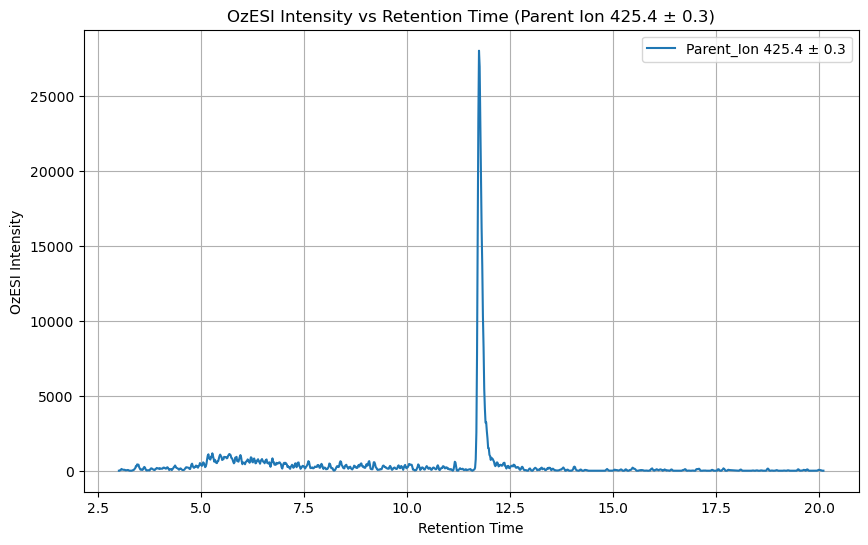

Unique Parent_Ion values within 425.4 ± 0.3: [425.4]


In [66]:
import matplotlib.pyplot as plt

def plot_ozesi_intensity(data, parent_ion, tolerance=0.3):
    """
    Plots OzESI_Intensity vs. Retention_Time for a specified Parent_Ion within a tolerance.
    Ensures the data is sorted by Retention_Time.

    Parameters:
    - data (pd.DataFrame): DataFrame containing the data to plot.
    - parent_ion (float): Target Parent_Ion value.
    - tolerance (float): Allowed deviation from the target Parent_Ion value.
    """
    # Filter data for the specified Parent_Ion within the tolerance
    filtered_data = data[(data['Parent_Ion'] >= parent_ion - tolerance) & 
                         (data['Parent_Ion'] <= parent_ion + tolerance)]

    if filtered_data.empty:
        print(f"No data found for Parent_Ion {parent_ion} ± {tolerance}.")
        return

    # Sort the filtered data by Retention_Time
    filtered_data = filtered_data.sort_values(by='Retention_Time')

    # Plot the data
    plt.figure(figsize=(10, 6))
    plt.plot(filtered_data['Retention_Time'], filtered_data['OzESI_Intensity'], label=f"Parent_Ion {parent_ion} ± {tolerance}")
    plt.title(f"OzESI Intensity vs Retention Time (Parent Ion {parent_ion} ± {tolerance})")
    plt.xlabel('Retention Time')
    plt.ylabel('OzESI Intensity')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage:
plot_ozesi_intensity(df, parent_ion=425.40, tolerance=0.3)


# Function to print unique Parent_Ion values within the given tolerance
def get_matching_parent_ions(data, parent_ion, tolerance=0.0001):
    """
    Prints unique Parent_Ion values within a specified tolerance.

    Parameters:
    - data (pd.DataFrame): DataFrame containing the data to filter.
    - parent_ion (float): Target Parent_Ion value.
    - tolerance (float): Allowed deviation from the target Parent_Ion value.
    """
    # Filter data for the specified Parent_Ion within the tolerance
    filtered_data = data[(data['Parent_Ion'] >= parent_ion - tolerance) &
                         (data['Parent_Ion'] <= parent_ion + tolerance)]
    unique_parent_ions = filtered_data['Parent_Ion'].unique()
    print(f"Unique Parent_Ion values within {parent_ion} ± {tolerance}: {unique_parent_ions}")

# Example usage
get_matching_parent_ions(df, parent_ion=425.40, tolerance=0.3)



# 3 - Match
#### input sample/ON
#### output match/ON

In [25]:
input_dir = 'Projects/STD/samples/ON/'
import glob; num_files = len(glob.glob(f'{input_dir}/*.parquet'))
num_files


1

In [3]:
# Submit the SLURM job for !sbatch core/backend/match_3.sh
!sbatch core/backend/STD/match_3_ON.sh


Submitted batch job 21069847


In [4]:
import pandas as pd
df = pd.read_parquet('Projects/STD/match/ON/df_match_3_FAME.parquet')
#print unqiue vlaues of Lipid in df
#print(df['Lipid'].unique())

df

filtered_df = df[(df['Species'] == '18:1') & (df['Parent_Ion'] == 339.3)]
# now do for 16:1 species
# filtered_df = df[(df['Species'] == '16:1')]
filtered_df

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,STD_Peak_Intensity,STD_Peak_Area,flat_baseline,STD_RT_Dif,Adjusted_RT,Species,Class,STD_RT_OFF
430024,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,339.3,183.0,11.495717,1421.0,FAME_OzoneOn,339.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,189.897474,-0.269483,11.226233,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
430025,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,339.3,183.0,11.511567,1258.0,FAME_OzoneOn,339.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,189.897474,-0.269483,11.242083,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
430026,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,339.3,183.0,11.527417,1134.0,FAME_OzoneOn,339.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,189.897474,-0.269483,11.257933,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
430027,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,339.3,183.0,11.543267,1098.0,FAME_OzoneOn,339.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,189.897474,-0.269483,11.273783,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
430028,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,339.3,183.0,11.559117,1099.0,FAME_OzoneOn,339.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,189.897474,-0.269483,11.289633,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442677,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,339.3,183.0,13.667367,664.0,FAME_OzoneOn,339.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,189.897474,-0.269483,13.397883,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
442678,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,339.3,183.0,13.683217,803.0,FAME_OzoneOn,339.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,189.897474,-0.269483,13.413733,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
442679,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,339.3,183.0,13.699067,749.0,FAME_OzoneOn,339.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,189.897474,-0.269483,13.429583,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
442680,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,339.3,183.0,13.714917,684.0,FAME_OzoneOn,339.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,189.897474,-0.269483,13.445433,18:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367


In [74]:
print(df['Retention_Time'].describe())


count    953175.000000
mean          7.872356
std           3.577489
min           3.005183
25%           5.245267
50%           6.604400
75%           9.853083
max          20.104000
Name: Retention_Time, dtype: float64


In [75]:
sorted_filtered_lipids = (
    df
    .loc[df['Lipid'].str.contains('24:1', case=False, na=False)]

)

sorted_filtered_lipids.head(30)


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,STD_Peak_Intensity,STD_Peak_Area,flat_baseline,STD_RT_Dif,Adjusted_RT,Species,Class,STD_RT_OFF


In [76]:
# Ensure 'Parent_Ion' is of float type
df['Parent_Ion'] = df['Parent_Ion'].astype(float)

# Define the target float value
target_value = 533.3

# Set a tolerance for floating-point comparison
tolerance = 0.3  # Adjust the tolerance as needed

# Filter the DataFrame for rows where 'Parent_Ion' is approximately equal to the target value
sorted_filtered_lipids = df.loc[(df['Parent_Ion'] >= target_value - tolerance) & 
                                (df['Parent_Ion'] <= target_value + tolerance)]

# Display the first 30 rows of the filtered DataFrame
sorted_filtered_lipids.head(30)


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,STD_Peak_Intensity,STD_Peak_Area,flat_baseline,STD_RT_Dif,Adjusted_RT,Species,Class,STD_RT_OFF
12229,,533.4,183.0,3.036950,41.0,FAME_OzoneOn,533.4 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,72.532069,-0.269483,2.767467,10:1,,11.475367
12230,,533.4,183.0,3.052800,41.0,FAME_OzoneOn,533.4 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,72.532069,-0.269483,2.783317,10:1,,11.475367
12231,,533.4,183.0,3.068650,40.0,FAME_OzoneOn,533.4 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,72.532069,-0.269483,2.799167,10:1,,11.475367
12232,,533.4,183.0,3.084500,40.0,FAME_OzoneOn,533.4 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,72.532069,-0.269483,2.815017,10:1,,11.475367
12233,,533.4,183.0,3.100350,41.0,FAME_OzoneOn,533.4 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,72.532069,-0.269483,2.830867,10:1,,11.475367
12234,,533.4,183.0,3.116217,47.0,FAME_OzoneOn,533.4 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,72.532069,-0.269483,2.846733,10:1,,11.475367
12235,,533.4,183.0,3.132067,48.0,FAME_OzoneOn,533.4 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,72.532069,-0.269483,2.862583,10:1,,11.475367
12236,,533.4,183.0,3.147917,47.0,FAME_OzoneOn,533.4 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,72.532069,-0.269483,2.878433,10:1,,11.475367
12237,,533.4,183.0,3.163767,41.0,FAME_OzoneOn,533.4 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,72.532069,-0.269483,2.894283,10:1,,11.475367
12238,,533.4,183.0,3.179617,66.0,FAME_OzoneOn,533.4 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,72.532069,-0.269483,2.910133,10:1,,11.475367


In [5]:
# # Ensure the Parent_Ion column is numeric
# df['Parent_Ion'] = pd.to_numeric(df['Parent_Ion'], errors='coerce')

# # Set tolerance for Parent_Ion comparison
# tolerance = 0.2

# # Filter based on Parent_Ion and Retention_Time window
# df_filtered = df[(df['Parent_Ion'] >= 423.4 - tolerance) & 
#                  (df['Parent_Ion'] <= 423.4 + tolerance) &
#                  (df['Retention_Time'] >= 14) &
#                  (df['Retention_Time'] <= 15) ]

# # Sort the filtered DataFrame by Retention_Time
# df_filtered_sorted = df_filtered.sort_values(by='Retention_Time', ascending=True)

# # Print each Lipid value on a new line
# for lipid in df_filtered_sorted['Lipid']:
#     print(lipid)


# # Display the sorted DataFrame
# df_filtered_sorted


In [77]:
df[df['Lipid'].str.contains('16:1', case=False, na=False)]

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,STD_Peak_Intensity,STD_Peak_Area,flat_baseline,STD_RT_Dif,Adjusted_RT,Species,Class,STD_RT_OFF
107,FA(6:2)_<F>_n-4 | FA(7:4)_<FFF>_n-5 | FA(9:1)_...,241.1,183.0,3.034817,41.0,FAME_OzoneOn,241.1 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,112.041768,-0.269483,2.765333,10:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
108,FA(6:2)_<F>_n-4 | FA(7:4)_<FFF>_n-5 | FA(9:1)_...,241.1,183.0,3.050667,126.0,FAME_OzoneOn,241.1 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,112.041768,-0.269483,2.781183,10:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
109,FA(6:2)_<F>_n-4 | FA(7:4)_<FFF>_n-5 | FA(9:1)_...,241.1,183.0,3.066517,169.0,FAME_OzoneOn,241.1 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,112.041768,-0.269483,2.797033,10:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
110,FA(6:2)_<F>_n-4 | FA(7:4)_<FFF>_n-5 | FA(9:1)_...,241.1,183.0,3.082383,183.0,FAME_OzoneOn,241.1 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,112.041768,-0.269483,2.812900,10:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
111,FA(6:2)_<F>_n-4 | FA(7:4)_<FFF>_n-5 | FA(9:1)_...,241.1,183.0,3.098233,152.0,FAME_OzoneOn,241.1 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,112.041768,-0.269483,2.828750,10:1,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947468,FA(16:1)_<>_n-2 | FA(17:1)_<>_n-3 | FA(17:3)_<...,409.3,183.0,7.465800,462.0,FAME_OzoneOn,409.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,172.673981,-0.269483,7.196317,9:3,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
947469,FA(16:1)_<>_n-2 | FA(17:1)_<>_n-3 | FA(17:3)_<...,409.3,183.0,7.481650,483.0,FAME_OzoneOn,409.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,172.673981,-0.269483,7.212167,9:3,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
947470,FA(16:1)_<>_n-2 | FA(17:1)_<>_n-3 | FA(17:3)_<...,409.3,183.0,7.497500,430.0,FAME_OzoneOn,409.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,172.673981,-0.269483,7.228017,9:3,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367
947471,FA(16:1)_<>_n-2 | FA(17:1)_<>_n-3 | FA(17:3)_<...,409.3,183.0,7.513367,331.0,FAME_OzoneOn,409.3 -> 183.0,FAME,FAME,11.74485,28002.021484,3394.648124,172.673981,-0.269483,7.243883,9:3,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,11.475367


In [8]:
# ozon_database = pd.read_parquet('lipid_database/OzON_databases/OzON_Possible_Database_0.parquet')
# ozon_database

# # Filter the OzON database for rows where Parent_Ion is 423.4
# filtered_data = ozon_database[ozon_database['Parent_Ion'] == 423.4]

# filtered_data


# 4 - group
#### input match/ON
#### output group/ON

In [5]:
input_dir = 'Projects/STD/match/ON/'
import glob; num_files = len(glob.glob(f'{input_dir}/*.parquet'))
num_files


1

In [5]:
!sbatch core/backend/STD/group_4_ON.sh

Submitted batch job 21069865


In [7]:
import pandas as pd
df_group = pd.read_parquet('Projects/STD/group/ON/df_group_4_FAME.parquet')
#print unqiue columns
print(df_group.columns)
df_group

Index(['Lipid', 'Parent_Ion', 'Product_Ion', 'Retention_Time',
       'OzESI_Intensity', 'Sample_ID', 'Transition', 'Sample', 'STD',
       'STD_RT_ON', 'STD_Peak_Intensity', 'STD_Peak_Area', 'flat_baseline',
       'STD_RT_Dif', 'Adjusted_RT', 'Species', 'Class', 'STD_RT_OFF',
       'Possible_Lipids', 'group_by_ion', 'group_by_lipid'],
      dtype='object')


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,...,STD_Peak_Area,flat_baseline,STD_RT_Dif,Adjusted_RT,Species,Class,STD_RT_OFF,Possible_Lipids,group_by_ion,group_by_lipid
0,FA(10:1)_<>_n-2,325.2,183.0,3.031750,41.0,FAME_OzoneOn,325.2 -> 183.0,FAME,FAME,11.74485,...,3394.648124,120.135881,-0.269483,2.762267,10:1,FA,11.475367,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,26,0
1,FA(10:1)_<>_n-2,325.2,183.0,3.047600,131.0,FAME_OzoneOn,325.2 -> 183.0,FAME,FAME,11.74485,...,3394.648124,120.135881,-0.269483,2.778117,10:1,FA,11.475367,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,26,0
2,FA(10:1)_<>_n-2,325.2,183.0,3.063450,254.0,FAME_OzoneOn,325.2 -> 183.0,FAME,FAME,11.74485,...,3394.648124,120.135881,-0.269483,2.793967,10:1,FA,11.475367,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,26,0
3,FA(10:1)_<>_n-2,325.2,183.0,3.079300,389.0,FAME_OzoneOn,325.2 -> 183.0,FAME,FAME,11.74485,...,3394.648124,120.135881,-0.269483,2.809817,10:1,FA,11.475367,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,26,0
4,FA(10:1)_<>_n-2,325.2,183.0,3.095150,452.0,FAME_OzoneOn,325.2 -> 183.0,FAME,FAME,11.74485,...,3394.648124,120.135881,-0.269483,2.825667,10:1,FA,11.475367,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,26,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241740,FA(9:3)_<FF>_n-7,241.1,183.0,7.473233,41.0,FAME_OzoneOn,241.1 -> 183.0,FAME,FAME,11.74485,...,3394.648124,54.802861,-0.269483,7.203750,9:3,FA,11.475367,FA(6:2)_<F>_n-4 | FA(7:4)_<FFF>_n-5 | FA(9:1)_...,0,1179
241741,FA(9:3)_<FF>_n-7,241.1,183.0,7.489083,41.0,FAME_OzoneOn,241.1 -> 183.0,FAME,FAME,11.74485,...,3394.648124,54.802861,-0.269483,7.219600,9:3,FA,11.475367,FA(6:2)_<F>_n-4 | FA(7:4)_<FFF>_n-5 | FA(9:1)_...,0,1179
241742,FA(9:3)_<FF>_n-7,241.1,183.0,7.504933,41.0,FAME_OzoneOn,241.1 -> 183.0,FAME,FAME,11.74485,...,3394.648124,54.802861,-0.269483,7.235450,9:3,FA,11.475367,FA(6:2)_<F>_n-4 | FA(7:4)_<FFF>_n-5 | FA(9:1)_...,0,1179
241743,FA(9:3)_<FF>_n-7,241.1,183.0,7.520783,41.0,FAME_OzoneOn,241.1 -> 183.0,FAME,FAME,11.74485,...,3394.648124,54.802861,-0.269483,7.251300,9:3,FA,11.475367,FA(6:2)_<F>_n-4 | FA(7:4)_<FFF>_n-5 | FA(9:1)_...,0,1179


In [8]:
sorted_filtered_lipids = (
    df_group
    # .loc[df_group['Lipid'].str.contains('24:1', case=False, na=False)]
    .assign(n_position=lambda x: x['Lipid'].str.extract(r'_n-(\d+)', expand=False))
    #.loc[lambda x: x['n_position'] == '9']
    .assign(Species='18:1')
    .sort_values(by='OzESI_Intensity', ascending=False)
    .reset_index(drop=True)
)

sorted_filtered_lipids.head(30)


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,...,flat_baseline,STD_RT_Dif,Adjusted_RT,Species,Class,STD_RT_OFF,Possible_Lipids,group_by_ion,group_by_lipid,n_position
0,FA(18:3)_<FF>_n-5,395.3,183.0,8.861467,1747941.0,FAME_OzoneOn,395.3 -> 183.0,FAME,FAME,11.74485,...,82.76699,-0.269483,8.591983,18:1,FA,11.475367,FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 | FA(16:1)_...,56,429,5
1,FA(20:5)_<FFFF>_n-7,395.3,183.0,8.861467,1747941.0,FAME_OzoneOn,395.3 -> 183.0,FAME,FAME,11.74485,...,82.76699,-0.269483,8.591983,18:1,FA,11.475367,FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 | FA(16:1)_...,56,703,7
2,FA(15:1)_<>_n-2,395.3,183.0,8.861467,1747941.0,FAME_OzoneOn,395.3 -> 183.0,FAME,FAME,11.74485,...,82.76699,-0.269483,8.591983,18:1,FA,11.475367,FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 | FA(16:1)_...,56,186,2
3,FA(15:1)_<>_n-2,395.3,183.0,8.861467,1747941.0,FAME_OzoneOn,395.3 -> 183.0,FAME,FAME,11.74485,...,82.76699,-0.269483,8.591983,18:1,FA,11.475367,FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 | FA(16:1)_...,56,186,2
4,FA(22:5)_<FFFF>_n-9,395.3,183.0,8.861467,1747941.0,FAME_OzoneOn,395.3 -> 183.0,FAME,FAME,11.74485,...,82.76699,-0.269483,8.591983,18:1,FA,11.475367,FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 | FA(16:1)_...,56,976,9
5,FA(18:3)_<FF>_n-5,395.3,183.0,8.861467,1747941.0,FAME_OzoneOn,395.3 -> 183.0,FAME,FAME,11.74485,...,82.76699,-0.269483,8.591983,18:1,FA,11.475367,FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 | FA(16:1)_...,56,429,5
6,FA(20:4)_<FFF>_n-7,395.3,183.0,8.861467,1747941.0,FAME_OzoneOn,395.3 -> 183.0,FAME,FAME,11.74485,...,82.76699,-0.269483,8.591983,18:1,FA,11.475367,FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 | FA(16:1)_...,56,634,7
7,FA(16:1)_<>_n-3,395.3,183.0,8.861467,1747941.0,FAME_OzoneOn,395.3 -> 183.0,FAME,FAME,11.74485,...,82.76699,-0.269483,8.591983,18:1,FA,11.475367,FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 | FA(16:1)_...,56,255,3
8,FA(16:1)_<>_n-3,395.3,183.0,8.861467,1747941.0,FAME_OzoneOn,395.3 -> 183.0,FAME,FAME,11.74485,...,82.76699,-0.269483,8.591983,18:1,FA,11.475367,FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 | FA(16:1)_...,56,255,3
9,FA(20:5)_<FFFF>_n-7,395.3,183.0,8.845617,1736912.0,FAME_OzoneOn,395.3 -> 183.0,FAME,FAME,11.74485,...,82.76699,-0.269483,8.576133,18:1,FA,11.475367,FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 | FA(16:1)_...,56,703,7


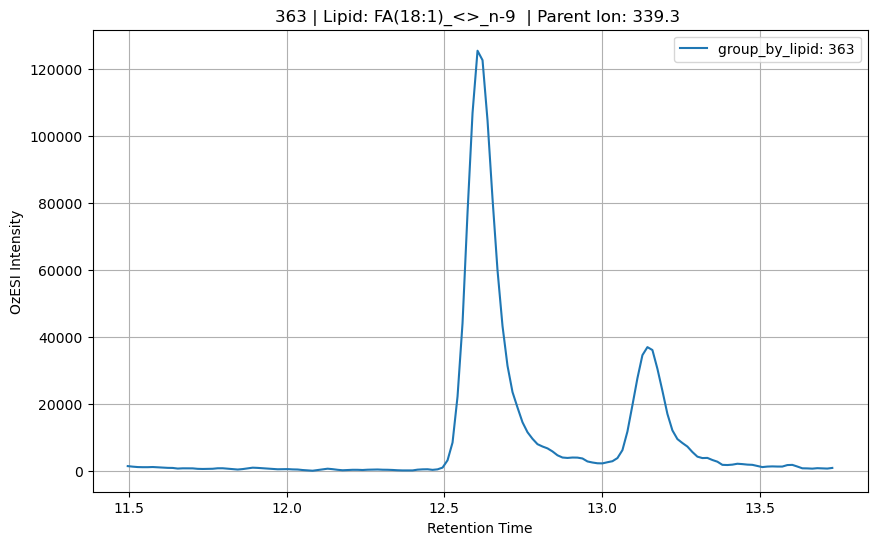

In [9]:
import matplotlib.pyplot as plt

# Function to plot the chromatogram for a specific group_by_lipid value
def plot_chromatogram(df, group_value):
    group_data = df[df['group_by_lipid'] == group_value]
    
    # Ensure the Retention_Time is sorted
    group_data = group_data.sort_values(by='Retention_Time')
    
    # Extract Lipid, Parent Ion, and Isomer values from the first row of the group
    lipid = group_data['Lipid'].iloc[0] if not group_data.empty else "Unknown Lipid"
    parent_ion = group_data['Parent_Ion'].iloc[0] if not group_data.empty else "Unknown Parent Ion"
    # isomer = group_data['Isomer'].iloc[0] if not group_data.empty else "Unknown Isomer"
    
    plt.figure(figsize=(10, 6))
    plt.plot(group_data['Retention_Time'], group_data['OzESI_Intensity'], label=f'group_by_lipid: {group_value}')
    plt.xlabel('Retention Time')
    plt.ylabel('OzESI Intensity')
    
    # Add Lipid, Parent Ion, and Isomer to the title
    plt.title(f'{group_value} | Lipid: {lipid} | Parent Ion: {parent_ion} ')
    
    plt.legend()
    plt.grid(True)
    plt.show()

# Define the specific group_by_lipid value you are interested in
specific_group_by_lipid_value = 363  # Replace with the actual value you are interested in

# Call the function to plot the chromatogram
plot_chromatogram(df_group, specific_group_by_lipid_value)


# 5 - Analysis

In [22]:
input_dir = 'Projects/STD/group/ON/'
import glob; num_files = len(glob.glob(f'{input_dir}/*.parquet'))
num_files



1

In [15]:
!sbatch core/backend/STD/analysis_5_ON.sh

Submitted batch job 21070271


In [16]:
import pandas as pd
df_analysis = pd.read_parquet('Projects/STD/analysis/ON/df_analysis_5_FAME.parquet')
#print number of unqiue values
#print(df_analysis['Lipid'].unique())
#print unique lipid values for Lipid FA(20:1)
# df_analysis
# df_analysis[df_analysis['Lipid'].str.contains('24:1', case=False, na=False)]
# df_analysis.to_csv('Projects/STD/analysis/ON/df_analysis_5_FAME.csv', index=False)
# Assuming df_analysis is your DataFrame
for index, row in df_analysis.iterrows():
    print(f"Lipid: {row['Lipid']}, Prominence: {row['Prominence']}")

df_analysis.head()




Lipid: FA(10:1)_<>_n-2 , Prominence: 1177.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 512.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 334.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 334.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 507.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 507.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 131.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 131.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 311.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 543061.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 984.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 850.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 1629.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 1234.0
Lipid: FA(10:1)_<>_n-3 , Prominence: 696.0
Lipid: FA(10:1)_<>_n-3 , Prominence: 261.0
Lipid: FA(10:1)_<>_n-3 , Prominence: 466.0
Lipid: FA(10:1)_<>_n-3 , Prominence: 128056.0
Lipid: FA(10:1)_<>_n-3 , Prominence: 261.0
Lipid: FA(10:1)_<>_n-3 , Prominence: 126.0
Lipid: FA(10:1)_<>_n-3 , Prominence: 340.0
Lipid: FA(10:1)_<>_n-3 , Prominence: 633.0
Lipid: FA(10:1)_<>_n-3 , Prominence: 430.0
Li

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,Possible_Lipids,Peak_Height,Prominence,FWHM,Peak_Width,Peak_Area,Filter_Column,STD_RT_ON,STD_RT_OFF,STD_RT_Dif,STD_Peak_Intensity,STD_Peak_Area,Adjusted_RT,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,flat_baseline,SN_Flat,SN_Sides,Normalized_Peak_Area,n_value
0,FA(10:1)_<>_n-2,3.142717,1243.0,26,0,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,10:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,1243.0,1177.0,0.081914,0.079267,74.838150,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,2.873233,11299.684543,-12321.766562,0.666667,6037.405139,1,120.135881,10.346617,13.313971,0.022046,2
1,FA(10:1)_<>_n-2,4.125500,677.0,26,0,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,10:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,677.0,512.0,0.087111,0.095117,50.451400,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,3.856017,6887.814724,-4258.675079,0.500000,3021.058371,0,120.135881,5.635286,3.169484,0.014862,2
2,FA(10:1)_<>_n-2,4.537633,853.0,26,0,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,10:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,853.0,334.0,0.094211,0.047550,36.565950,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,4.268150,10337.990086,-9553.853087,0.200000,6098.034458,0,120.135881,7.100293,0.008599,0.010772,2
3,FA(10:1)_<>_n-2,4.537633,853.0,26,0,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,10:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,853.0,334.0,0.094211,0.047550,36.565950,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,4.268150,10337.990086,-9553.853087,0.200000,6098.034458,0,120.135881,7.100293,0.008599,0.010772,2
4,FA(10:1)_<>_n-2,4.632750,970.0,26,0,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,10:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,970.0,507.0,0.124433,0.063417,53.730933,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,4.363267,10328.977017,-7796.304642,1.666667,-548.132040,1,120.135881,8.074191,0.009813,0.015828,2


In [17]:
#print columns of df_analysis
print(df_analysis.columns)
filtered_lipids = df_analysis[df_analysis['Lipid'].str.contains('18:1', case=False, na=False)]
# filter for Lipid FA(18:1)_<>_n-9
filtered_lipids = filtered_lipids[filtered_lipids['Lipid'].str.contains('18:1', case=False, na=False)]
filtered_lipids = filtered_lipids[filtered_lipids['Lipid'].str.contains('n-9', case=False, na=False)]
sorted_filtered_lipids = filtered_lipids.sort_values(by='OzESI_Intensity', ascending=False)
# print(sorted_filtered_lipids['Species'].unique())

# print(sorted_filtered_lipids.columns)
# set columns to display all
pd.set_option('display.max_columns', None)
sorted_filtered_lipids = sorted_filtered_lipids.sort_values(by='Lipid', ascending=True)
sorted_filtered_lipids.head()

Index(['Lipid', 'Retention_Time', 'OzESI_Intensity', 'group_by_ion',
       'group_by_lipid', 'Sample_ID', 'Transition', 'Sample', 'Parent_Ion',
       'Product_Ion', 'Species', 'Class', 'Possible_Lipids', 'Peak_Height',
       'Prominence', 'FWHM', 'Peak_Width', 'Peak_Area', 'Filter_Column',
       'STD_RT_ON', 'STD_RT_OFF', 'STD_RT_Dif', 'STD_Peak_Intensity',
       'STD_Peak_Area', 'Adjusted_RT', 'Slope_Left', 'Slope_Right',
       'Asymmetry_Factor', 'Baseline_Drift', 'Shoulder_Count', 'flat_baseline',
       'SN_Flat', 'SN_Sides', 'Normalized_Peak_Area', 'n_value'],
      dtype='object')


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,Possible_Lipids,Peak_Height,Prominence,FWHM,Peak_Width,Peak_Area,Filter_Column,STD_RT_ON,STD_RT_OFF,STD_RT_Dif,STD_Peak_Intensity,STD_Peak_Area,Adjusted_RT,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,flat_baseline,SN_Flat,SN_Sides,Normalized_Peak_Area,n_value
2084,FA(18:1)_<>_n-9,12.605317,125471.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,125471.0,124807.0,0.194621,0.095117,9503.577158,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.335833,1.962518e+06,-724344.299234,1.400000,274705.798475,1,189.897474,660.730221,10.823112,2.799577,9
2085,FA(18:1)_<>_n-9,12.605317,125471.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,125471.0,124807.0,0.194621,0.095117,9503.577158,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.335833,1.962518e+06,-724344.299234,1.400000,274705.798475,1,189.897474,660.730221,10.823112,2.799577,9
2088,FA(18:1)_<>_n-9,13.144267,36950.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,36950.0,34714.0,0.200158,0.110950,3220.585275,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.874783,4.661199e+05,-225308.697612,0.857143,132108.793044,1,189.897474,194.578681,4.858460,0.948724,9
2089,FA(18:1)_<>_n-9,13.144267,36950.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,36950.0,34714.0,0.200158,0.110950,3220.585275,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.874783,4.661199e+05,-225308.697612,0.857143,132108.793044,1,189.897474,194.578681,4.858460,0.948724,9
2086,FA(18:1)_<>_n-9,12.906500,3983.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,3983.0,121.0,0.057664,0.031700,125.104050,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.637017,-2.247859e+04,-9941.415052,3.000000,2370.437134,0,189.897474,20.974476,0.121815,0.036853,9


In [18]:
import pandas as pd

# Set option to display full column width
#pd.set_option('display.max_colwidth', None)
#reset set option
pd.reset_option('display.max_colwidth')
# Filter rows where 'Species' is '18:1'
filtered_df = df_analysis[df_analysis['Species'] == '18:1']
# # and also filter for n_value = 4
# filtered_df = filtered_df[filtered_df['n_value'] == 4]
#print unique column names
print(filtered_df.columns)
# print Possible_Lipids column
print(filtered_df['Possible_Lipids'])
filtered_df


Index(['Lipid', 'Retention_Time', 'OzESI_Intensity', 'group_by_ion',
       'group_by_lipid', 'Sample_ID', 'Transition', 'Sample', 'Parent_Ion',
       'Product_Ion', 'Species', 'Class', 'Possible_Lipids', 'Peak_Height',
       'Prominence', 'FWHM', 'Peak_Width', 'Peak_Area', 'Filter_Column',
       'STD_RT_ON', 'STD_RT_OFF', 'STD_RT_Dif', 'STD_Peak_Intensity',
       'STD_Peak_Area', 'Adjusted_RT', 'Slope_Left', 'Slope_Right',
       'Asymmetry_Factor', 'Baseline_Drift', 'Shoulder_Count', 'flat_baseline',
       'SN_Flat', 'SN_Sides', 'Normalized_Peak_Area', 'n_value'],
      dtype='object')
2028    FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...
2029    FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...
2030    FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...
2031    FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...
2032    FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...
                              ...                        
2093    FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,Possible_Lipids,Peak_Height,Prominence,FWHM,Peak_Width,Peak_Area,Filter_Column,STD_RT_ON,STD_RT_OFF,STD_RT_Dif,STD_Peak_Intensity,STD_Peak_Area,Adjusted_RT,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,flat_baseline,SN_Flat,SN_Sides,Normalized_Peak_Area,n_value
2028,FA(18:1)_<>_n-2,11.759967,2015.0,74,356,FAME_OzoneOn,437.4 -> 183.0,FAME,437.4,183.0,18:1,FA,FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...,2015.0,1884.0,0.090905,0.095100,147.745775,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,11.490483,21305.993691,-18910.258420,0.500000,8630.013520,1,47.281591,42.617009,13.713842,0.043523,2
2029,FA(18:1)_<>_n-2,12.140400,540.0,74,356,FAME_OzoneOn,437.4 -> 183.0,FAME,437.4,183.0,18:1,FA,FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...,540.0,304.0,0.087738,0.047550,21.365800,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,11.870917,10256.872465,-9647.483015,1.000000,2018.927445,1,47.281591,11.420936,1.516346,0.006294,2
2030,FA(18:1)_<>_n-2,12.140400,540.0,74,356,FAME_OzoneOn,437.4 -> 183.0,FAME,437.4,183.0,18:1,FA,FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...,540.0,304.0,0.087738,0.047550,21.365800,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,11.870917,10256.872465,-9647.483015,1.000000,2018.927445,1,47.281591,11.420936,1.516346,0.006294,2
2031,FA(18:1)_<>_n-2,12.330617,510.0,74,356,FAME_OzoneOn,437.4 -> 183.0,FAME,437.4,183.0,18:1,FA,FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...,510.0,76.0,0.062062,0.031700,15.525075,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.061133,7219.468229,-2460.567823,3.000000,234.339793,0,47.281591,10.786439,3.919823,0.004573,2
2032,FA(18:1)_<>_n-2,12.330617,510.0,74,356,FAME_OzoneOn,437.4 -> 183.0,FAME,437.4,183.0,18:1,FA,FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...,510.0,76.0,0.062062,0.031700,15.525075,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.061133,7219.468229,-2460.567823,3.000000,234.339793,0,47.281591,10.786439,3.919823,0.004573,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2093,FA(18:1)_<>_n-10,12.701133,634.0,26,349,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,18:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,634.0,540.0,0.338882,0.174367,87.081192,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.431650,6372.239748,-3855.479396,3.400000,100.098463,2,120.135881,5.277358,5.179128,0.025652,10
2094,FA(18:1)_<>_n-10,12.701133,634.0,26,349,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,18:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,634.0,540.0,0.338882,0.174367,87.081192,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.431650,6372.239748,-3855.479396,3.400000,100.098463,2,120.135881,5.277358,5.179128,0.025652,10
2095,FA(18:1)_<>_n-10,12.764550,580.0,26,349,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,18:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,580.0,76.0,0.060480,0.031700,17.530100,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.495067,-2432.851496,-1550.247859,3.000000,901.306895,0,120.135881,4.827867,4.096258,0.005164,10
2096,FA(18:1)_<>_n-10,12.764550,580.0,26,349,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,18:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,580.0,76.0,0.060480,0.031700,17.530100,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.495067,-2432.851496,-1550.247859,3.000000,901.306895,0,120.135881,4.827867,4.096258,0.005164,10


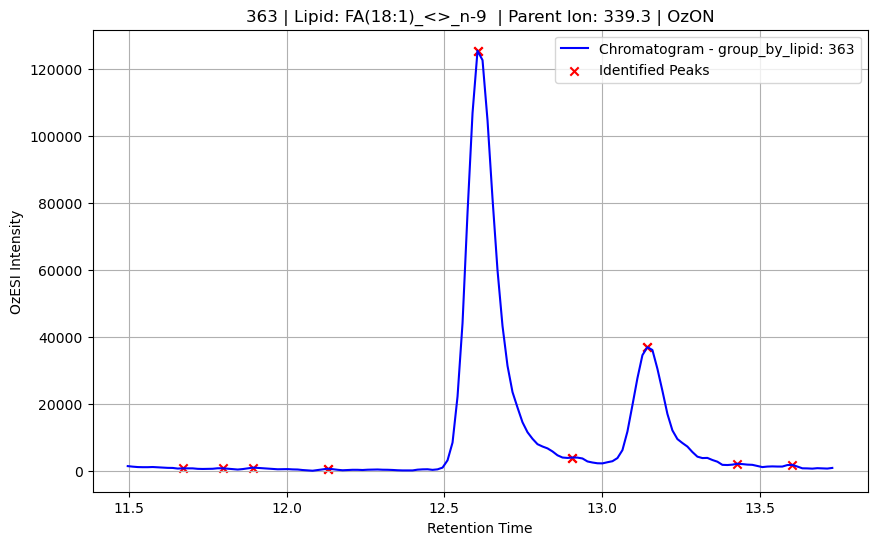

In [19]:
import matplotlib.pyplot as plt

# Function to plot the chromatogram for a specific group_by_lipid value, including analysis data (peaks)
def plot_chromatogram(df_grouped, df_analysis, group_value):
    """
    Plot the chromatogram for a specific group_by_lipid value.

    :param df_grouped: DataFrame containing the original grouped data.
    :param df_analysis: DataFrame containing the analyzed data (peaks).
    :param group_value: The specific group_by_lipid value to plot.
    """
    # Filter data for the specific group_by_lipid value
    group_data = df_grouped[df_grouped['group_by_lipid'] == group_value]
    analysis_data = df_analysis[df_analysis['group_by_lipid'] == group_value]
    
    # Ensure the Retention_Time is sorted in both DataFrames
    group_data = group_data.sort_values(by='Retention_Time')
    analysis_data = analysis_data.sort_values(by='Retention_Time')

    # Extract Lipid, Parent Ion, and Isomer values from the first row of the group
    lipid = group_data['Lipid'].iloc[0] if not group_data.empty else "Unknown Lipid"
    parent_ion = group_data['Parent_Ion'].iloc[0] if not group_data.empty else "Unknown Parent Ion"
    # isomer = group_data['Isomer'].iloc[0] if not group_data.empty else "Unknown Isomer"
    
    # Plot the grouped data (original chromatogram)
    plt.figure(figsize=(10, 6))
    plt.plot(group_data['Retention_Time'], group_data['OzESI_Intensity'], label=f'Chromatogram - group_by_lipid: {group_value}', color='blue')
    
    # Overlay the analysis data (peaks)
    if not analysis_data.empty:
        plt.scatter(analysis_data['Retention_Time'], analysis_data['OzESI_Intensity'], color='red', marker='x', label='Identified Peaks')

    # Add labels and title
    plt.xlabel('Retention Time')
    plt.ylabel('OzESI Intensity')
    
    # Add Lipid, Parent Ion, and Isomer to the title
    plt.title(f'{group_value} | Lipid: {lipid} | Parent Ion: {parent_ion} | OzON')
    
    # Add a legend and grid
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    plt.show()

# Example: Define the specific group_by_lipid value you are interested in
specific_group_by_lipid_value = 363 # Replace with the actual value you are interested in

# Call the function to plot the chromatogram and analysis data
plot_chromatogram(df_group, df_analysis, specific_group_by_lipid_value)


# plot with zoom in

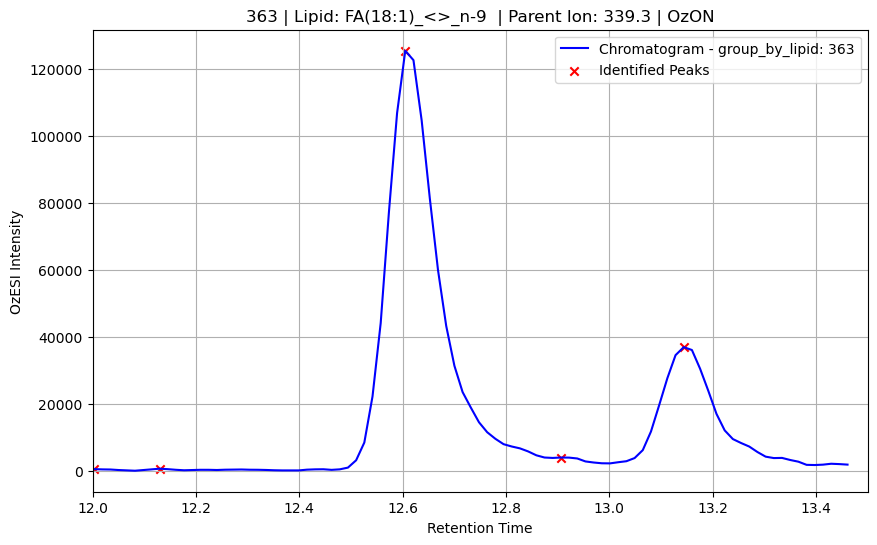

In [30]:
import matplotlib.pyplot as plt

# Function to plot the chromatogram for a specific group_by_lipid value, including analysis data (peaks)
def plot_chromatogram(df_grouped, df_analysis, group_value, retention_start=None, retention_end=None):
    """
    Plot the chromatogram for a specific group_by_lipid value with an optional retention time range.

    :param df_grouped: DataFrame containing the original grouped data.
    :param df_analysis: DataFrame containing the analyzed data (peaks).
    :param group_value: The specific group_by_lipid value to plot.
    :param retention_start: (Optional) The start value for Retention_Time to zoom in.
    :param retention_end: (Optional) The end value for Retention_Time to zoom in.
    """
    # Filter data for the specific group_by_lipid value
    group_data = df_grouped[df_grouped['group_by_lipid'] == group_value]
    analysis_data = df_analysis[df_analysis['group_by_lipid'] == group_value]
    
    # Ensure the Retention_Time is sorted in both DataFrames
    group_data = group_data.sort_values(by='Retention_Time')
    analysis_data = analysis_data.sort_values(by='Retention_Time')

    # If retention_start and/or retention_end are provided, filter the data accordingly
    if retention_start is not None:
        group_data = group_data[group_data['Retention_Time'] >= retention_start]
        analysis_data = analysis_data[analysis_data['Retention_Time'] >= retention_start]
    
    if retention_end is not None:
        group_data = group_data[group_data['Retention_Time'] <= retention_end]
        analysis_data = analysis_data[analysis_data['Retention_Time'] <= retention_end]

    # Extract Lipid, Parent Ion, and Isomer values from the first row of the group
    lipid = group_data['Lipid'].iloc[0] if not group_data.empty else "Unknown Lipid"
    parent_ion = group_data['Parent_Ion'].iloc[0] if not group_data.empty else "Unknown Parent Ion"
    # isomer = group_data['Isomer'].iloc[0] if not group_data.empty else "Unknown Isomer"
    
    # Plot the grouped data (original chromatogram)
    plt.figure(figsize=(10, 6))
    plt.plot(
        group_data['Retention_Time'], 
        group_data['OzESI_Intensity'], 
        label=f'Chromatogram - group_by_lipid: {group_value}', 
        color='blue'
    )
    
    # Overlay the analysis data (peaks)
    if not analysis_data.empty:
        plt.scatter(
            analysis_data['Retention_Time'], 
            analysis_data['OzESI_Intensity'], 
            color='red', 
            marker='x', 
            label='Identified Peaks'
        )

    # Add labels and title
    plt.xlabel('Retention Time')
    plt.ylabel('OzESI Intensity')
    
    # Add Lipid, Parent Ion, and Isomer to the title
    plt.title(f'{group_value} | Lipid: {lipid} | Parent Ion: {parent_ion} | OzON')
    
    # Set x-axis limits if retention_start and/or retention_end are provided
    if retention_start is not None or retention_end is not None:
        plt.xlim(
            left=retention_start if retention_start is not None else group_data['Retention_Time'].min(),
            right=retention_end if retention_end is not None else group_data['Retention_Time'].max()
        )
    
    # Add a legend and grid
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    plt.show()

# Example: Define the specific group_by_lipid value and retention time range you are interested in
specific_group_by_lipid_value = 363  # Replace with the actual value you are interested in
retention_time_start = 12         # Replace with your desired start Retention_Time
retention_time_end = 13.5     # Replace with your desired end Retention_Time

# Call the function to plot the chromatogram and analysis data with the specified retention time range
plot_chromatogram(
    df_group, 
    df_analysis, 
    specific_group_by_lipid_value, 
    retention_start=retention_time_start, 
    retention_end=retention_time_end
)


# quick viewing of Species and N value to get group numbers to see plots

In [20]:
filtered_df = df_analysis[(df_analysis['Species'] == '18:1') & (df_analysis['n_value'] == 9)]
#filtered_df = filtered_df[['Species', 'n_value']]
filtered_df


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,Possible_Lipids,Peak_Height,Prominence,FWHM,Peak_Width,Peak_Area,Filter_Column,STD_RT_ON,STD_RT_OFF,STD_RT_Dif,STD_Peak_Intensity,STD_Peak_Area,Adjusted_RT,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,flat_baseline,SN_Flat,SN_Sides,Normalized_Peak_Area,n_value
2079,FA(18:1)_<>_n-9,11.670067,760.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,760.0,74.0,0.042342,0.047567,35.270892,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,11.400583,-5.425868e+03,-3072.555205,2.000000,1078.282120,0,189.897474,4.002160,2.360633,0.010390,9
2080,FA(18:1)_<>_n-9,11.796883,777.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,777.0,209.0,0.040120,0.031700,23.402525,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,11.527400,2.485804e+03,1153.535715,0.000000,4700.315457,0,189.897474,4.091682,2.490225,0.006894,9
2081,FA(18:1)_<>_n-9,11.892000,952.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,952.0,554.0,0.071432,0.079250,63.233575,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,11.622517,1.153536e+03,-6403.785489,1.500000,1485.353763,1,189.897474,5.013232,3.073989,0.018627,9
2082,FA(18:1)_<>_n-9,12.129767,647.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,647.0,512.0,0.091815,0.047550,22.855700,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,11.860283,1.201442e+04,-10572.329878,1.000000,5683.086629,1,189.897474,3.407102,0.250637,0.006733,9
2083,FA(18:1)_<>_n-9,12.129767,647.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,647.0,512.0,0.091815,0.047550,22.855700,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,11.860283,1.201442e+04,-10572.329878,1.000000,5683.086629,1,189.897474,3.407102,0.250637,0.006733,9
2084,FA(18:1)_<>_n-9,12.605317,125471.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,125471.0,124807.0,0.194621,0.095117,9503.577158,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.335833,1.962518e+06,-724344.299234,1.400000,274705.798475,1,189.897474,660.730221,10.823112,2.799577,9
2085,FA(18:1)_<>_n-9,12.605317,125471.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,125471.0,124807.0,0.194621,0.095117,9503.577158,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.335833,1.962518e+06,-724344.299234,1.400000,274705.798475,1,189.897474,660.730221,10.823112,2.799577,9
2086,FA(18:1)_<>_n-9,12.906500,3983.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,3983.0,121.0,0.057664,0.031700,125.104050,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.637017,-2.247859e+04,-9941.415052,3.000000,2370.437134,0,189.897474,20.974476,0.121815,0.036853,9
2087,FA(18:1)_<>_n-9,12.906500,3983.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,3983.0,121.0,0.057664,0.031700,125.104050,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.637017,-2.247859e+04,-9941.415052,3.000000,2370.437134,0,189.897474,20.974476,0.121815,0.036853,9
2088,FA(18:1)_<>_n-9,13.144267,36950.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,36950.0,34714.0,0.200158,0.110950,3220.585275,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,12.874783,4.661199e+05,-225308.697612,0.857143,132108.793044,1,189.897474,194

In [21]:
# Assuming df_analysis is the new DataFrame in question
# We are filtering it to only include the specified columns if they exist

# List of required columns
required_columns = ['Lipid', 'Retention_Time', 'Prominence', 'Slope_Left', 'Slope_Right','Asymmetry_Factor', 'Baseline_Drift', 'Shoulder_Count','Normalized_Peak_Area']

# Filter df_analysis for specified columns only if they exist
filtered_df_analysis = df_analysis.loc[:, [col for col in required_columns if col in df_analysis.columns]]
# filter ony for Lipid FA(16:1)
filtered_df_analysis = filtered_df_analysis[filtered_df_analysis['Lipid'].str.contains('16:1', na=False)]


# Display all columns in filtered_df_analysis
filtered_df_analysis


,Lipid,Retention_Time,Prominence,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,Normalized_Peak_Area
1352,FA(16:1)_<>_n-2,8.654683,457.0,1243.245607,-6012.618297,1.000000,3646.508326,1,0.009510
1353,FA(16:1)_<>_n-2,8.844900,290.0,24182.965300,-8048.670572,0.500000,11630.063454,0,0.017012
1354,FA(16:1)_<>_n-2,8.844900,290.0,24182.965300,-8048.670572,0.500000,11630.063454,0,0.017012
1355,FA(16:1)_<>_n-2,8.908300,1849.0,4677.782785,-29220.369536,0.454545,-482.798926,2,0.072136
1356,FA(16:1)_<>_n-2,8.908300,1849.0,4677.782785,-29220.369536,0.454545,-482.798926,2,0.072136
...,...,...,...,...,...,...,...,...,...
1430,FA(16:1)_<>_n-10,10.071233,150.0,-16115.367283,-5930.599369,3.000000,1388.902259,1,0.005466
1431,FA(16:1)_<>_n-10,10.071233,150.0,-16115.367283,-5930.599369,3.000000,1388.902259,1,0.005466
1432,FA(16:1)_<>_n-11,9.120733,2740.0,40442.404066,-30482.199189,1.000000,10958.883806,1,0.049581
1433,FA(16:1)_<>_n-11,9.120733,2740.0,40442.404066,-30482.199189,1.000000,10958.883806,1,0.049581


# 6 - loading filter Function for OzON OzOFF from python file 

In [21]:
# print len of dir
input_dir = 'Projects/STD/analysis/OFF/off_possible/'
input_dir2 = 'Projects/STD/analysis/ON/'
import glob; num_files = len(glob.glob(f'{input_dir}/*.parquet'))
import glob; num_files2 = len(glob.glob(f'{input_dir2}/*.parquet'))

print(num_files)
print(num_files2)   

1
1


In [1]:
import pandas as pd
from core.python.isomer_filter_6_AMP import filter_ozON_by_ozOFF

# Define input and output directories
input_dir = 'Projects/STD/analysis/ON/'
off_possible_dir = 'Projects/STD/analysis/OFF/off_possible/'
isomer_filter_output = 'Projects/STD/isomer_filter_6/'

# Call the function to process all parquet files in the input directory
filter_ozON_by_ozOFF(input_dir, off_possible_dir, retention_time_tolerance=0.15, isomer_filter_output=isomer_filter_output)

# Example usage:
# filter_ozON_by_ozOFF(
#     input_dir='path/to/OzON',
#     off_possible_dir='path/to/OzOFF',
#     retention_time_tolerance=0.3,
#     isomer_filter_output='Projects/AMP/isomer_filter_6/'
# )

# OzOFF directory: Projects/STD/analysis/OFF/off_possible/
# OzON directory: Projects/STD/analysis/ON/

# OzOFF Keys:
# 1. File: df_analysis_5_FAME_OFF_offpossible.parquet
#    Key: FAME_OFF_offpossible


# OzON Keys:
# 1. File: df_analysis_5_FAME.parquet
#    Key: FAME


Starting file matching process...
Looking for parquet files in:
OzOFF directory: Projects/STD/analysis/OFF/off_possible/
OzON directory: Projects/STD/analysis/ON/

OzOFF Keys:
1. File: df_analysis_5_FAME_OFF_offpossible.parquet
   Key: FAME_OFF_offpossible


OzON Keys:
1. File: df_analysis_5_FAME.parquet
   Key: FAME


Found 0 matched file pairs

Matched Pairs:

Unmatched files:
OzOFF file without match: df_analysis_5_FAME_OFF_offpossible.parquet (Key: FAME_OFF_offpossible)
OzON file without match: df_analysis_5_FAME.parquet (Key: FAME)


In [22]:
import pandas as pd
from core.python.isomer_filter_6_AMP import filter_ozON_by_ozOFF
# Define directories
input_directory = 'Projects/STD/analysis/ON/'
off_possible_directory = 'Projects/STD/analysis/OFF/off_possible/'
output_directory = 'Projects/STD/isomer_filter_6/'

# Specify specific files to match (ensure these are exact filenames)
specific_ozoff_files = ['df_analysis_5_FAME_OFF_offpossible.parquet']  # Correct filename
specific_ozon_files = ['df_analysis_5_FAME.parquet']                  # Correct filename

# Call the function with specific files
filter_ozON_by_ozOFF(
    input_dir=input_directory,
    off_possible_dir=off_possible_directory,
    retention_time_tolerance=0.15,
    isomer_filter_output=output_directory,
    specific_off_files=specific_ozoff_files,
    specific_on_files=specific_ozon_files
)

INFO: 
Starting file matching process...
INFO: Looking for parquet files in:
INFO: OzOFF directory: Projects/STD/analysis/OFF/off_possible/
INFO: OzON directory: Projects/STD/analysis/ON/
INFO: 
OzOFF Keys:
INFO: 1. File: df_analysis_5_FAME_OFF_offpossible.parquet | Key: FAME
INFO: 
OzON Keys:
INFO: 1. File: df_analysis_5_FAME.parquet | Key: FAME
INFO: 
Found 1 matched file pairs
INFO: 
Matched Pairs:
INFO: 
Match 1:
INFO: Key: FAME
INFO: OzOFF: df_analysis_5_FAME_OFF_offpossible.parquet
INFO: OzON: df_analysis_5_FAME.parquet
INFO: 
Processing matched pair with key: FAME
INFO: OzON file: df_analysis_5_FAME.parquet
INFO: OzOFF file: df_analysis_5_FAME_OFF_offpossible.parquet
INFO: Matching OzON: Lipid=FA(10:1)_<>_n-2  (n-2), Adjusted_RT=2.8732333333333333 with OzOFF: Species=10:1, Isomer=1, Retention_Time=3.8712666666666666
INFO: Result: No Match
INFO: Matching OzON: Lipid=FA(10:1)_<>_n-2  (n-2), Adjusted_RT=3.856016666666667 with OzOFF: Species=10:1, Isomer=1, Retention_Time=3.87126666

# seems good up to here

In [24]:
import pandas as pd
df = pd.read_parquet('Projects/STD/isomer_filter_6/FAME_isomer_filtered_6.parquet')

# df = df[df['Lipid'].str.contains('20:1', case=False, na=False)]
# df = df.sort_values(by='OzESI_Intensity', ascending=False)
#print unqiue values of Lipid in df
# print(df['Lipid'].unique())
# #print unique columns
print(df.columns)
df

# Reorder columns: Move 'Adjusted_RT' to position 3 (index 2, next to 'Retention_Time')
columns = list(df.columns)
if 'Adjusted_RT' in columns:
    columns.remove('Adjusted_RT')  # Remove 'Adjusted_RT' from its current position
    columns.insert(2, 'Adjusted_RT')  # Insert 'Adjusted_RT' at index 2 (3rd position)
    df = df[columns]  # Reorder DataFrame columns
    
filtered_lipids = df[df['Lipid'].str.contains('18:1', case=False, na=False)]
# filtered_lipids = df[df['Lipid'].str.contains('16:1', case=False, na=False)]
# filtered_lipids = df[df['Lipid'].str.contains('18:3', case=False, na=False)]
sorted_filtered_lipids = filtered_lipids.sort_values(by='OzESI_Intensity', ascending=False)
# print(sorted_filtered_lipids['Species'].unique())

# print(sorted_filtered_lipids.columns)
sorted_filtered_lipids = sorted_filtered_lipids.sort_values(by='Lipid', ascending=True)
sorted_filtered_lipids



Index(['Lipid', 'Retention_Time', 'OzESI_Intensity', 'group_by_ion',
       'group_by_lipid', 'Sample_ID', 'Transition', 'Sample', 'Parent_Ion',
       'Product_Ion', 'Species', 'Class', 'Possible_Lipids', 'Peak_Height',
       'Prominence', 'FWHM', 'Peak_Width', 'Peak_Area', 'Filter_Column',
       'STD_RT_ON', 'STD_RT_OFF', 'STD_RT_Dif', 'STD_Peak_Intensity',
       'STD_Peak_Area', 'Adjusted_RT', 'Slope_Left', 'Slope_Right',
       'Asymmetry_Factor', 'Baseline_Drift', 'Shoulder_Count', 'flat_baseline',
       'SN_Flat', 'SN_Sides', 'Normalized_Peak_Area', 'n_value', 'n_position',
       'OzOFF_Isomer'],
      dtype='object')


,Lipid,Retention_Time,Adjusted_RT,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,Possible_Lipids,Peak_Height,Prominence,FWHM,Peak_Width,Peak_Area,Filter_Column,STD_RT_ON,STD_RT_OFF,STD_RT_Dif,STD_Peak_Intensity,STD_Peak_Area,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,flat_baseline,SN_Flat,SN_Sides,Normalized_Peak_Area,n_value,n_position,OzOFF_Isomer
661,FA(18:1)_<>_n-10,12.701133,12.431650,634.0,26,349,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,18:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,634.0,540.0,0.338882,0.174367,87.081192,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,6.372240e+03,-3855.479396,3.400000,100.098463,2,120.135881,5.277358,5.179128,0.025652,10,10,1.0
660,FA(18:1)_<>_n-10,12.701133,12.431650,634.0,26,349,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,18:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,634.0,540.0,0.338882,0.174367,87.081192,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,6.372240e+03,-3855.479396,3.400000,100.098463,2,120.135881,5.277358,5.179128,0.025652,10,10,1.0
673,FA(18:1)_<>_n-10,13.224250,12.954767,636.0,26,349,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,18:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,636.0,584.0,0.247699,0.190217,90.187075,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,3.460999e+03,-2365.930599,0.454545,1430.070438,2,120.135881,5.294005,4.125230,0.026567,10,10,2.0
662,FA(18:1)_<>_n-2,13.107350,12.837867,613.0,74,356,FAME_OzoneOn,437.4 -> 183.0,FAME,437.4,183.0,18:1,FA,FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...,613.0,47.0,0.059211,0.031700,19.004150,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,-3.875620e+02,-2712.933754,3.000000,1018.476791,0,47.281591,12.964877,0.047640,0.005598,2,2,2.0
663,FA(18:1)_<>_n-2,13.107350,12.837867,613.0,74,356,FAME_OzoneOn,437.4 -> 183.0,FAME,437.4,183.0,18:1,FA,FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...,613.0,47.0,0.059211,0.031700,19.004150,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,-3.875620e+02,-2712.933754,3.000000,1018.476791,0,47.281591,12.964877,0.047640,0.005598,2,2,2.0
667,FA(18:1)_<>_n-3,13.155767,12.886283,1270.0,68,357,FAME_OzoneOn,423.3 -> 183.0,FAME,423.3,183.0,18:1,FA,FA(17:1)_<>_n-2 | FA(18:1)_<>_n-3 | FA(18:2)_<...,1270.0,90.0,0.033645,0.015850,19.138875,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,-1.174403e+04,402.814851,1.000000,7886.435331,0,94.385086,13.455516,1.993371,0.005638,3,3,2.0
666,FA(18:1)_<>_n-3,13.155767,12.886283,1270.0,68,357,FAME_OzoneOn,423.3 -> 183.0,FAME,423.3,183.0,18:1,FA,FA(17:1)_<>_n-2 | FA(18:1)_<>_n-3 | FA(18:2)_<...,1270.0,90.0,0.033645,0.015850,19.138875,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,-1.174403e+04,402.814851,1.000000,7886.435331,0,94.385086,13.455516,1.993371,0.005638,3,3,2.0
668,FA(18:1)_<>_n-3,13.235017,12.965533,1798.0,68,357,FAME_OzoneOn,423.3 -> 183.0,FAME,423.3,183.0,18:1,FA,FA(17:1)_<>_n-2 | FA(18:1)_<>_n-3 | FA(18:2)_<...,1798.0,653.0,0.048093,0.047550,77.807650,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,7.661904e+03,-5638.069221,0.500000,8145.110410,0,94.385086,19.049620,3.051020,0.022921,3,3,2.0
665,FA(18:1)_<>_n-3,13.092367,12.822883,1961.0,68,357,FAME_OzoneOn,423.3 -> 183.0,FAME,423.3,183.0,18:1,FA,FA(17:1)_<>_n-2 | FA(18:1)_<>_n-3 | FA(18:2)_<...,1961.0,902.0,0.083687,0.047567,77.527958,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,1.728707e+04,-23947.724200,1.000000,7678.390561,1,94.385086,20.776588,2.620611,0.022838,3,3,2.0
655,FA(18:1)_<>_n-3,12.743617,12.474133,2866.0,68,357,FAME_OzoneOn,423.3 -> 183.0,FAME,423.3,183.0,18:1,FA,FA(17:1)_<>_n-2 | FA(18:1)_<>_n-3 | FA(18:2)_<...,2866.0,175.0,0.087325,0.047550,133.710600,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,-5.975665e+03,-7832.356918,1.000000,202

# 7 - top 2 and remove n-2 to n-4

In [25]:
import pandas as pd

def process_df(df):
    # Ensure 'n_value' and 'OzESI_Intensity' are numeric
    df['n_value'] = pd.to_numeric(df['n_value'], errors='coerce')
    df['OzESI_Intensity'] = pd.to_numeric(df['OzESI_Intensity'], errors='coerce')
    
    # Filter out rows where 'n_value' equals 2, 3, or 4
    df_filtered = df[~df['n_value'].isin([2,4])]
    
    # For each combination of 'Lipid', 'OzOFF_Isomer', and 'n_value',
    # select the row with the highest 'OzESI_Intensity'
    df_result = df_filtered.loc[
        df_filtered.groupby(['Lipid', 'OzOFF_Isomer', 'n_value'])['OzESI_Intensity'].idxmax()
    ]
    
    return df_result.reset_index(drop=True)

# Assuming 'df' is your DataFrame
result_df = process_df(df)
# save to parquet
result_df.to_parquet('Projects/STD/isomer_filter_6/top2_7/df_top2_7_FAME.parquet')
result_df



,Lipid,Retention_Time,Adjusted_RT,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,Possible_Lipids,Peak_Height,Prominence,FWHM,Peak_Width,Peak_Area,Filter_Column,STD_RT_ON,STD_RT_OFF,STD_RT_Dif,STD_Peak_Intensity,STD_Peak_Area,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,flat_baseline,SN_Flat,SN_Sides,Normalized_Peak_Area,n_value,n_position,OzOFF_Isomer
0,FA(10:1)_<>_n-3,4.253017,3.983533,973.0,20,1,FAME_OzoneOn,311.3 -> 183.0,FAME,311.3,183.0,10:1,FA,FA(9:1)_<>_n-2 | FA(10:1)_<>_n-3 | FA(10:3)_<F...,973.0,466.0,0.105378,0.110967,92.088300,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,10290.220820,-2927.444795,1.333333,1381.611503,1,59.146036,16.450807,0.035861,0.027127,3,3,1.0
1,FA(10:1)_<>_n-3,5.552850,5.283367,800.0,20,1,FAME_OzoneOn,311.3 -> 183.0,FAME,311.3,183.0,10:1,FA,FA(9:1)_<>_n-2 | FA(10:1)_<>_n-3 | FA(10:3)_<F...,800.0,430.0,0.045838,0.047567,32.845758,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,3205.047319,-5179.810726,0.500000,3613.819405,0,59.146036,13.525843,2.473166,0.009676,3,3,2.0
2,FA(10:1)_<>_n-5,4.206767,3.937283,916.0,9,3,FAME_OzoneOn,283.2 -> 183.0,FAME,283.2,183.0,10:1,FA,FA(9:1)_<>_n-4 | FA(9:3)_<FF>_n-4 | FA(10:1)_<...,916.0,217.0,0.049278,0.047567,41.843025,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,2397.476341,-258.929703,2.000000,2251.194029,0,45.455241,20.151691,4.734039,0.012326,5,5,1.0
3,FA(10:1)_<>_n-6,4.238950,3.969467,1564.0,5,4,FAME_OzoneOn,269.1 -> 183.0,FAME,269.1,183.0,10:1,FA,FA(6:2)_<F>_n-2 | FA(9:1)_<>_n-5 | FA(9:3)_<FF...,1564.0,609.0,0.043208,0.047550,67.061350,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,2654.807821,-2712.933754,0.500000,4529.968454,0,53.463179,29.253779,5.886478,0.019755,6,6,1.0
4,FA(10:3)_<BB>_n-5,5.966517,5.697033,1442.0,7,10,FAME_OzoneOn,279.2 -> 183.0,FAME,279.2,183.0,10:3,FA,FA(7:4)_<BBF>_n-2 | FA(9:3)_<BB>_n-4 | FA(10:3...,1442.0,1401.0,0.159206,0.079250,88.522250,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,26561.514196,-8778.729157,1.000000,10281.469421,1,244.371447,5.900853,9.176324,0.026077,5,5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,FA(23:5)_<FFFF>_n-9,5.452683,5.183200,945.0,62,1147,FAME_OzoneOn,409.3 -> 183.0,FAME,409.3,183.0,23:5,FA,FA(16:1)_<>_n-2 | FA(17:1)_<>_n-3 | FA(17:3)_<...,945.0,260.0,0.153799,0.079267,69.287033,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,7043.533576,-2009.914376,1.000000,1521.857659,0,57.387306,16.467056,3.691757,0.020411,9,9,1.0
558,FA(23:5)_<FFFF>_n-9,5.674600,5.405117,1119.0,62,1147,FAME_OzoneOn,409.3 -> 183.0,FAME,409.3,183.0,23:5,FA,FA(16:1)_<>_n-2 | FA(17:1)_<>_n-3 | FA(17:3)_<...,1119.0,689.0,0.103983,0.047550,48.524775,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,11689.950428,-5903.560162,5.000000,1395.292405,1,57.387306,19.499086,5.147905,0.014294,9,9,2.0
559,FA(9:1)_<>_n-5,4.714483,4.445000,779.0,5,1163,FAME_OzoneOn,269.1 -> 183.0,FAME,269.1,183.0,9:1,FA,FA(6:2)_<F>_n-2 | FA(9:1)_<>_n-5 | FA(9:3)_<FF...,779.0,333.0,0.105206,0.047567,33.955283,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,3181.613339,-3162.242968,5.000000,43.316111,1,53.463179,14.570776,2.202897,0.010003,5,5,1.0
560,FA(9:1)_<>_n-5,4.968117,4.698633,540.0,5,1163,FAME_OzoneOn,269.1 -> 183.0,FAME,269.1,183.0,9:1,FA,FA(6:2)_<F>_n-2 | FA(9:1)_<>_n-5 | FA(9:3)_<FF...,540.0,363.0,0.099765,0.047550,22.792300,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,6431.390125,-10860.748085,1.000000,3237.078379,0,53.463179,10.100410,2.917598,0.006714,5,5,2.0


In [26]:
# Reorder columns: Move 'Adjusted_RT' to position 3 (index 2, next to 'Retention_Time')
columns = list(result_df.columns)
if 'Adjusted_RT' in columns:
    columns.remove('Adjusted_RT')  # Remove 'Adjusted_RT' from its current position
    columns.insert(2, 'Adjusted_RT')  # Insert 'Adjusted_RT' at index 2 (3rd position)
    result_df = result_df[columns]  # Reorder DataFrame columns
    
filtered_lipids = result_df[result_df['Lipid'].str.contains('18:1', case=False, na=False)]
# filtered_lipids = result_df[result_df['Lipid'].str.contains('16:1', case=False, na=False)]
#filtered_lipids = result_df[result_df['Lipid'].str.contains('15:1', case=False, na=False)]
sorted_filtered_lipids = filtered_lipids.sort_values(by='OzESI_Intensity', ascending=False)
# print(sorted_filtered_lipids['Species'].unique())

# print(sorted_filtered_lipids.columns)
sorted_filtered_lipids = sorted_filtered_lipids.sort_values(by='Lipid', ascending=True)
sorted_filtered_lipids

,Lipid,Retention_Time,Adjusted_RT,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,Possible_Lipids,Peak_Height,Prominence,FWHM,Peak_Width,Peak_Area,Filter_Column,STD_RT_ON,STD_RT_OFF,STD_RT_Dif,STD_Peak_Intensity,STD_Peak_Area,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,flat_baseline,SN_Flat,SN_Sides,Normalized_Peak_Area,n_value,n_position,OzOFF_Isomer
150,FA(18:1)_<>_n-10,13.224250,12.954767,636.0,26,349,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,18:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,636.0,584.0,0.247699,0.190217,90.187075,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,3.460999e+03,-2365.930599,0.454545,1430.070438,2,120.135881,5.294005,4.125230,0.026567,10,10,2.0
149,FA(18:1)_<>_n-10,12.701133,12.431650,634.0,26,349,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,18:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,634.0,540.0,0.338882,0.174367,87.081192,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,6.372240e+03,-3855.479396,3.400000,100.098463,2,120.135881,5.277358,5.179128,0.025652,10,10,1.0
151,FA(18:1)_<>_n-3,12.490000,12.220517,7159.0,68,357,FAME_OzoneOn,423.3 -> 183.0,FAME,423.3,183.0,18:1,FA,FA(17:1)_<>_n-2 | FA(18:1)_<>_n-3 | FA(18:2)_<...,7159.0,1494.0,0.072638,0.031700,218.309975,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,4.815683e+04,-33050.923840,0.333333,27733.213159,0,94.385086,75.848848,0.897315,0.064310,3,3,1.0
152,FA(18:1)_<>_n-3,13.092367,12.822883,1961.0,68,357,FAME_OzoneOn,423.3 -> 183.0,FAME,423.3,183.0,18:1,FA,FA(17:1)_<>_n-2 | FA(18:1)_<>_n-3 | FA(18:2)_<...,1961.0,902.0,0.083687,0.047567,77.527958,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,1.728707e+04,-23947.724200,1.000000,7678.390561,1,94.385086,20.776588,2.620611,0.022838,3,3,2.0
153,FA(18:1)_<>_n-7,12.492917,12.223433,640.0,44,361,FAME_OzoneOn,367.3 -> 183.0,FAME,367.3,183.0,18:1,FA,FA(13:1)_<>_n-2 | FA(14:1)_<>_n-3 | FA(15:1)_<...,640.0,599.0,0.222255,0.110967,54.120017,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,9.098232e+03,-5705.272645,1.800000,93.997666,1,53.040941,12.066151,8.492170,0.015943,7,7,1.0
154,FA(18:1)_<>_n-8,13.111850,12.842367,679.0,38,362,FAME_OzoneOn,353.3 -> 183.0,FAME,353.3,183.0,18:1,FA,FA(12:1)_<>_n-2 | FA(13:1)_<>_n-3 | FA(14:1)_<...,679.0,638.0,0.227181,0.110967,58.288100,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,3.704371e+03,-9391.617846,0.555556,922.063153,1,77.244768,8.790239,7.597925,0.017171,8,8,2.0
155,FA(18:1)_<>_n-9,12.605317,12.335833,125471.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,125471.0,124807.0,0.194621,0.095117,9503.577158,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,1.962518e+06,-724344.299234,1.400000,274705.798475,1,189.897474,660.730221,10.823112,2.799577,9,9,1.0
156,FA(18:1)_<>_n-9,13.144267,12.874783,36950.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,36950.0,34714.0,0.200158,0.110950,3220.585275,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,4.661199e+05,-225308.697612,0.857143,132108.793044,1,189.897474,194.578681,4.858460,0.948724,9,9,2.0


In [29]:
off_possible = pd.read_parquet('Projects/STD/analysis/OFF/off_possible/df_analysis_5_FAME_OFF_offpossible.parquet')
#print unique columns
print(off_possible.columns)
#print species 18:1
off_possible[off_possible['Species'] == '18:1']
# off_possible

Index(['Lipid', 'Retention_Time', 'OzESI_Intensity', 'group_by_ion',
       'group_by_lipid', 'Sample_ID', 'Transition', 'Sample', 'Parent_Ion',
       'Product_Ion', 'Species', 'Class', 'STD', 'STD_RT_OFF', 'Peak_Height',
       'FWHM', 'Peak_Width', 'Peak_Area', 'Filter_Column', 'Isomer'],
      dtype='object')


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,Isomer
34,FA(18:1),12.3300,324899.0,81,50,FAME_OzoneOff,449.4 -> 183.0,FAME,449.4,183.0,18:1,FA,FAME,11.475367,324899.0,0.107350,0.11095,36047.54405,group_by_lipid,1
35,FA(18:1),12.8848,77485.0,81,50,FAME_OzoneOff,449.4 -> 183.0,FAME,449.4,183.0,18:1,FA,FAME,11.475367,77485.0,0.107298,0.11095,8596.96075,group_by_lipid,2


8 - Offpossible vs top2 ON

In [27]:
import pandas as pd

def offpossible_top2_8(off_possible_path='Projects/STD/analysis/OFF/off_possible/df_analysis_5_FAME_OFF_offpossible.parquet',
                      top2_7_path='Projects/STD/isomer_filter_6/top2_7/df_top2_7_FAME.parquet',
                      rt_window=0.3):
    """
    Filter top2_7 DataFrame based on matching records from OFF possible dataset within
    specified retention time windows.
    
    Parameters:
    -----------
    off_possible_path : str
        Path to the OFF possible parquet file
    top2_7_path : str
        Path to the top2_7 parquet file
    rt_window : float
        Retention time window (plus/minus) for matching (default: 0.3)
        
    Returns:
    --------
    pandas.DataFrame
        Filtered top2_7 DataFrame containing only rows that match the criteria
    """
    try:
        # Read the parquet files
        off_possible = pd.read_parquet(off_possible_path)
        top2_7 = pd.read_parquet(top2_7_path)
        
        # Create mask for matching rows
        mask = pd.Series(False, index=top2_7.index)
        
        # Iterate through off_possible records
        for _, off_row in off_possible.iterrows():
            # Define retention time window
            rt_min = off_row['Retention_Time'] - rt_window
            rt_max = off_row['Retention_Time'] + rt_window
            
            # Update mask for matching records
            current_matches = (
                (top2_7['Adjusted_RT'] >= rt_min) &
                (top2_7['Adjusted_RT'] <= rt_max) &
                (top2_7['Species'] == off_row['Species']) &
                (top2_7['OzOFF_Isomer'] == off_row['Isomer'])
            )
            mask = mask | current_matches
        
        # Filter top2_7 DataFrame
        filtered_top2_7 = top2_7[mask].copy()
        
        return filtered_top2_7
    
    except FileNotFoundError as e:
        print(f"Error: Could not find one of the parquet files: {e}")
        return None
    except Exception as e:
        print(f"Error processing data: {e}")
        return None
    
    
result = offpossible_top2_8(rt_window=0.05)
# save to parquet
result.to_parquet('Projects/STD/isomer_filter_6/offpossiblematch_8/df_offpossiblematch_8_FAME.parquet')




In [28]:
result

,Lipid,Retention_Time,Adjusted_RT,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,Possible_Lipids,Peak_Height,Prominence,FWHM,Peak_Width,Peak_Area,Filter_Column,STD_RT_ON,STD_RT_OFF,STD_RT_Dif,STD_Peak_Intensity,STD_Peak_Area,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,flat_baseline,SN_Flat,SN_Sides,Normalized_Peak_Area,n_value,n_position,OzOFF_Isomer
1,FA(10:1)_<>_n-3,5.552850,5.283367,800.0,20,1,FAME_OzoneOn,311.3 -> 183.0,FAME,311.3,183.0,10:1,FA,FA(9:1)_<>_n-2 | FA(10:1)_<>_n-3 | FA(10:3)_<F...,800.0,430.0,0.045838,0.047567,32.845758,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,3.205047e+03,-5179.810726,0.500000,3613.819405,0,59.146036,13.525843,2.473166,0.009676,3,3,2.0
4,FA(10:3)_<BB>_n-5,5.966517,5.697033,1442.0,7,10,FAME_OzoneOn,279.2 -> 183.0,FAME,279.2,183.0,10:3,FA,FA(7:4)_<BBF>_n-2 | FA(9:3)_<BB>_n-4 | FA(10:3...,1442.0,1401.0,0.159206,0.079250,88.522250,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,2.656151e+04,-8778.729157,1.000000,10281.469421,1,244.371447,5.900853,9.176324,0.026077,5,5,1.0
6,FA(10:3)_<FF>_n-7,7.060850,6.791367,601.0,2,22,FAME_OzoneOn,255.2 -> 183.0,FAME,255.2,183.0,10:3,FA,FA(6:2)_<F>_n-3 | FA(7:4)_<FFF>_n-4 | FA(9:1)_...,601.0,560.0,0.142146,0.142667,61.433425,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,3.217666e+02,-984.227129,3.500000,-260.386073,2,42.379050,14.181535,5.379932,0.018097,7,7,2.0
7,FA(11:1)_<>_n-3,4.870517,4.601033,1352.0,26,44,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,11:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,1352.0,311.0,0.053159,0.047567,58.640875,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,5.336036e+03,415400.630915,0.000000,4427.886285,0,120.135881,11.253923,0.010120,0.017275,3,3,1.0
8,FA(11:1)_<>_n-3,6.043517,5.774033,3476.0,26,44,FAME_OzoneOn,325.2 -> 183.0,FAME,325.2,183.0,11:1,FA,FA(10:1)_<>_n-2 | FA(11:1)_<>_n-3 | FA(11:3)_<...,3476.0,1234.0,0.056532,0.047550,153.111000,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,1.556467e+04,-1798.194631,0.500000,7066.246057,0,120.135881,28.933904,2.906545,0.045104,3,3,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,FA(23:5)_<FFFF>_n-14,5.488000,5.218517,53821.0,32,1136,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,23:5,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,53821.0,52698.0,0.136835,0.063400,2853.768725,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,1.074060e+06,-546083.821541,1.666667,108411.897251,1,189.897474,283.421358,14.224805,0.840667,14,14,1.0
553,FA(23:5)_<FFFF>_n-5,5.623983,5.354500,744.0,86,1143,FAME_OzoneOn,465.3 -> 183.0,FAME,465.3,183.0,23:5,FA,FA(20:1)_<>_n-2 | FA(20:2)_<F>_n-2 | FA(22:1)_...,744.0,606.0,0.137289,0.063417,40.057192,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,9.472735e+03,-10590.356016,0.600000,2516.273485,1,81.393974,9.140726,6.645008,0.011800,5,5,2.0
554,FA(23:5)_<FFFF>_n-7,5.451083,5.181600,639.0,74,1145,FAME_OzoneOn,437.4 -> 183.0,FAME,437.4,183.0,23:5,FA,FA(18:1)_<>_n-2 | FA(18:2)_<F>_n-2 | FA(19:1)_...,639.0,439.0,0.124199,0.063400,34.545075,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,6.417305e+03,-6804.867057,1.666667,915.727805,1,47.281591,13.514774,5.491537,0.010176,7,7,1.0
557,FA(23:5)_<FFFF>_n-9,5.452683,5.183200,945.0,62,1147,FAME_OzoneOn,409.3 -> 183.0,FAME,409.3,183.0,23:5,FA,FA(16:1)_<>_n-2 | FA(17:1)_<>_n-3 | FA(17:3)_<...,945.0,260.0,0.153799,0.079267,69.287033,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,7.043534e+03,-2009.914376,1.000000,1521.857659,0,57.387306,16.467056,3.691757,0.020411,9,9,1.0


In [31]:
import pandas as pd
df8 = pd.read_parquet('Projects/STD/isomer_filter_6/offpossiblematch_8/df_offpossiblematch_8_FAME.parquet')
# df7.to_csv('Projects/AMP/fame_filter_7/csv/hippo_WT_m1_FAD245_fame_filter_7.csv', index=False)


filtered_lipids = df8[df8['Lipid'].str.contains('18:1', case=False, na=False)]
sorted_filtered_lipids = filtered_lipids.sort_values(by='OzESI_Intensity', ascending=False)
# print(sorted_filtered_lipids['Species'].unique())
sorted_filtered_lipids = sorted_filtered_lipids.sort_values(by='Lipid', ascending=True)

# #print unique columns
# print(sorted_filtered_lipids.columns)
# #print value STD_RT_ON
# print(sorted_filtered_lipids['STD_RT_ON'].unique())
sorted_filtered_lipids

# df7

,Lipid,Retention_Time,Adjusted_RT,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,Possible_Lipids,Peak_Height,Prominence,FWHM,Peak_Width,Peak_Area,Filter_Column,STD_RT_ON,STD_RT_OFF,STD_RT_Dif,STD_Peak_Intensity,STD_Peak_Area,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,flat_baseline,SN_Flat,SN_Sides,Normalized_Peak_Area,n_value,n_position,OzOFF_Isomer
154,FA(18:1)_<>_n-8,13.111850,12.842367,679.0,38,362,FAME_OzoneOn,353.3 -> 183.0,FAME,353.3,183.0,18:1,FA,FA(12:1)_<>_n-2 | FA(13:1)_<>_n-3 | FA(14:1)_<...,679.0,638.0,0.227181,0.110967,58.288100,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,3.704371e+03,-9391.617846,0.555556,922.063153,1,77.244768,8.790239,7.597925,0.017171,8,8,2.0
155,FA(18:1)_<>_n-9,12.605317,12.335833,125471.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,125471.0,124807.0,0.194621,0.095117,9503.577158,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,1.962518e+06,-724344.299234,1.400000,274705.798475,1,189.897474,660.730221,10.823112,2.799577,9,9,1.0
156,FA(18:1)_<>_n-9,13.144267,12.874783,36950.0,32,363,FAME_OzoneOn,339.3 -> 183.0,FAME,339.3,183.0,18:1,FA,FA(11:1)_<>_n-2 | FA(12:1)_<>_n-3 | FA(12:3)_<...,36950.0,34714.0,0.200158,0.110950,3220.585275,group_by_lipid,11.74485,11.475367,-0.269483,28002.021484,3394.648124,4.661199e+05,-225308.697612,0.857143,132108.793044,1,189.897474,194.578681,4.858460,0.948724,9,9,2.0


# NEXT STEP move to NOT POSSIBLE notebook

# PLOT 

In [30]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import zipfile

# Function to create bar plots of Lipid vs Max OzESI_Intensity, separated by Species and OzOFF_Isomer for each parquet file
def plot_max_lipid_intensity_by_species_and_OzOFF_Isomer(input_plot_files, output_base_folder, zip_output_path, save_option="both"):
    """
    Load parquet files from the input directory, create separate bar plots of Lipid vs Max OzESI_Intensity for each 
    unique combination of Species and OzOFF_Isomer, and save them as PNG files in subdirectories based on the Sample column.
    Compress all PNG files into a ZIP archive, depending on user option.

    :param input_plot_files: Path to the directory containing parquet files.
    :param output_base_folder: Base path where the plot folders will be created for each sample.
    :param zip_output_path: Path to the output ZIP file where all PNG files will be saved.
    :param save_option: Choose "both" to save PNGs and ZIP or "zip" to save only the ZIP file.
    """
    # Ensure the output base folder exists, create it if it doesn't
    if not os.path.exists(output_base_folder):
        os.makedirs(output_base_folder)

    # List to keep track of all the generated PNG file paths
    png_files = []
    
    print(f"Output base folder: {output_base_folder}")
    
    # Loop through each parquet file in the input directory
    for file_name in os.listdir(input_plot_files):
        if file_name.endswith('.parquet'):
            # Load the parquet file into a DataFrame
            file_path = os.path.join(input_plot_files, file_name)
            df = pd.read_parquet(file_path)

            # Group the DataFrame by Species, OzOFF_Isomer, Lipid, and Sample, and take the max OzESI_Intensity for each group
            df_max_intensity = df.groupby(['Species', 'OzOFF_Isomer', 'Lipid', 'Sample'])['OzESI_Intensity'].max().reset_index()

            # Get unique combinations of Species, OzOFF_Isomer, and Sample
            unique_combinations = df_max_intensity[['Species', 'OzOFF_Isomer', 'Sample']].drop_duplicates()

            for _, row in unique_combinations.iterrows():
                species = row['Species']
                OzOFF_Isomer = row['OzOFF_Isomer']
                sample = row['Sample']

                # Filter the grouped DataFrame by the current Species, OzOFF_Isomer, and Sample
                filtered_data = df_max_intensity[
                    (df_max_intensity['Species'] == species) &
                    (df_max_intensity['OzOFF_Isomer'] == OzOFF_Isomer) &
                    (df_max_intensity['Sample'] == sample)
                ]

                # Sort the lipids by intensity for better visualization
                filtered_data = filtered_data.sort_values(by='OzESI_Intensity', ascending=False)

                # Create a bar plot for the current Species, OzOFF_Isomer, and Sample
                plt.figure(figsize=(12, 6))
                plt.bar(filtered_data['Lipid'], filtered_data['OzESI_Intensity'], color='skyblue')

                # Add labels and title
                plt.xlabel('Lipid')
                plt.ylabel('Max OzESI Intensity')
                plt.title(f'Lipid vs Max OzESI Intensity | Sample: {sample} Species: {species} | OzOFF_Isomer: {OzOFF_Isomer}')

                # Rotate x-axis labels for better readability
                plt.xticks(rotation=90)

                plt.tight_layout()

                # Only create sample directories and save PNGs if the user chose to save both PNG and ZIP
                if save_option == "both":
                    # Create output directory for the sample if it doesn't exist
                    sample_output_folder = os.path.join(output_base_folder, sample)
                    if not os.path.exists(sample_output_folder):
                        os.makedirs(sample_output_folder)

                    # Replace any colons with underscores in the species name for the file name
                    safe_species_name = species.replace(':', '_')

                    # Save the plot as a PNG file
                    output_file = os.path.join(sample_output_folder, f'Lipid_vs_OzESI_Intensity_{sample}_{safe_species_name}_OzOFF_Isomer_{OzOFF_Isomer}.png')
                    plt.savefig(output_file, format='png')
                    plt.close()  # Close the plot to avoid displaying it while saving
                    
                    # Add the PNG file to the list
                    png_files.append(output_file)

            if save_option == "both":
                print(f"Saved PNGs for Sample: {sample} in {sample_output_folder}")

    # Create a ZIP file and add all the PNG files (even if 'zip' is selected, we still ZIP the files)
    with zipfile.ZipFile(zip_output_path, 'w') as zipf:
        for png_file in png_files:
            zipf.write(png_file, os.path.basename(png_file))

    print(f"ZIP file created at: {zip_output_path}")

# Example usage
#input_plot_files = 'Projects/STD/fame_filter_7/'  
input_plot_files = 'Projects/STD/isomer_filter_6/offpossiblematch_8/'
output_folder = 'Projects/STD/plots/ON_plots/'
zip_output_path = 'Projects/STD/plots/OzESI_Intensity_plots.zip'  # Define the path to save the ZIP file
plot_max_lipid_intensity_by_species_and_OzOFF_Isomer(input_plot_files, output_folder, zip_output_path, save_option="both")


Output base folder: Projects/STD/plots/ON_plots/
Saved PNGs for Sample: FAME in Projects/STD/plots/ON_plots/FAME
ZIP file created at: Projects/STD/plots/OzESI_Intensity_plots.zip
